## **INTRODUCTION**

### Problem Statement

Educational institutions often need reliable ways to identify students who may be at risk of poor academic performance and provide appropriate support. However, assessing student performance can be challenging because academic outcomes are influenced by multiple factors, including previous academic achievement, study habits, attendance, demographic characteristics, and socioeconomic conditions.

This project aims to develop a machine learning classification model that categorizes students into different academic performance levels based on available academic, demographic, and socioeconomic factors. The model will classify students into performance categories such as Excellent, Good, Average, and Poor based on their academic outcomes.

### Importance of the Problem

Early identification of students who may require additional academic support can help educational institutions implement targeted interventions. Understanding the factors associated with different performance levels can assist teachers, administrators, and policymakers in making data-driven decisions to improve student outcomes.

### Expected Impact

The developed machine learning solution is expected to provide a data-driven approach for classifying student performance levels. The insights generated from the model can support early intervention strategies, resource allocation, and the development of personalized academic support programs for students.

In [1]:
import pandas as pd
from google.colab import files
uploaded = files.upload()

Saving bangladesh_student_performance.csv to bangladesh_student_performance.csv


In [2]:
df=pd.read_csv("bangladesh_student_performance.csv")
df.head()

,Student_ID,Gender,Age,District,School_Type,Study_Hours_per_Week,Attendance,Parent_Education,Family_Income_BDT,Internet_Access,Private_Tuition,Previous_GPA,SSC_Result,HSC_Result
0,1,Male,16,Rangpur,Private,11,70,Graduate,49169,Yes,Yes,4.83,4.22,5.00
1,2,Female,17,Rajshahi,Private,7,76,Primary,57947,No,No,4.96,4.09,4.77
2,3,Male,15,Barisal,Private,27,63,Higher Secondary,57224,Yes,Yes,4.32,4.86,4.62
3,4,Male,15,Mymensingh,Private,18,84,Primary,55865,No,No,4.63,3.54,3.75
4,5,Male,15,Mymensingh,Public,28,89,Higher Secondary,35553,No,Yes,4.50,4.65,3.46


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Student_ID            1000 non-null   int64  
 1   Gender                1000 non-null   object 
 2   Age                   1000 non-null   int64  
 3   District              1000 non-null   object 
 4   School_Type           1000 non-null   object 
 5   Study_Hours_per_Week  1000 non-null   int64  
 6   Attendance            1000 non-null   int64  
 7   Parent_Education      1000 non-null   object 
 8   Family_Income_BDT     1000 non-null   int64  
 9   Internet_Access       1000 non-null   object 
 10  Private_Tuition       1000 non-null   object 
 11  Previous_GPA          1000 non-null   float64
 12  SSC_Result            1000 non-null   float64
 13  HSC_Result            1000 non-null   float64
dtypes: float64(3), int64(5), object(6)
memory usage: 109.5+ KB


In [4]:
df.shape

(1000, 14)

In [5]:
df.isnull().sum()

,0
Student_ID,0
Gender,0
Age,0
District,0
School_Type,0
Study_Hours_per_Week,0
Attendance,0
Parent_Education,0
Family_Income_BDT,0
Internet_Access,0


The dataset was checked for missing values and no missing values were found, therefore no missing value imputation was needed.

In [6]:
df.duplicated().sum()

np.int64(0)

The dataset was also checked for duplicate records and non were found.

In [7]:
df.drop("Student_ID", axis=1,inplace=True)

Student ID was dropped because it is just an identifier and it does not contain any predictive information.

# **CREATING THE TARGET VARIABLE**

The original dataset contains HSC_Result as a numerical academic outcome. For this classification project, HSC_Result was transformed into categorical performance levels. This allows the machine learning model to classify students into different academic performance categories rather than predicting an exact numerical score.

The performance categories were defined as follows:

- Excellent: HSC_Result ≥ 4.5
- Good: HSC_Result between 4.0 and 4.49
- Average: HSC_Result < 4.0

The poor category was not included because no students in the dataset fell within that range.


In [10]:
def performance_category(score):
   if score >= 4.5:
       return "Excellent"
   elif score <= 4.0:
       return "Good"
   else:
       return "Average"
df["Final_Result_Class"] = df["HSC_Result"].apply(performance_category)
df.head()


,Gender,Age,District,School_Type,Study_Hours_per_Week,Attendance,Parent_Education,Family_Income_BDT,Internet_Access,Private_Tuition,Previous_GPA,SSC_Result,HSC_Result,Final_Result_Class
0,Male,16,Rangpur,Private,11,70,Graduate,49169,Yes,Yes,4.83,4.22,5.00,Excellent
1,Female,17,Rajshahi,Private,7,76,Primary,57947,No,No,4.96,4.09,4.77,Excellent
2,Male,15,Barisal,Private,27,63,Higher Secondary,57224,Yes,Yes,4.32,4.86,4.62,Excellent
3,Male,15,Mymensingh,Private,18,84,Primary,55865,No,No,4.63,3.54,3.75,Good
4,Male,15,Mymensingh,Public,28,89,Higher Secondary,35553,No,Yes,4.50,4.65,3.46,Good


In [11]:
df["Final_Result_Class"].value_counts()

,count
Final_Result_Class,
Good,499
Excellent,268
Average,233


# **REMOVING ORIGINAL TARGET VARIABLE**

HSC_Result was used to create the Final_Result_Class target variable.The original numerical value was removed from the data to prevent leakage during model training.This ensures that the model learns from student characteristics rather than directly accessing the outcome it is expected to predict.

In [12]:
df.drop("HSC_Result", axis=1,inplace=True)
df.head()

,Gender,Age,District,School_Type,Study_Hours_per_Week,Attendance,Parent_Education,Family_Income_BDT,Internet_Access,Private_Tuition,Previous_GPA,SSC_Result,Final_Result_Class
0,Male,16,Rangpur,Private,11,70,Graduate,49169,Yes,Yes,4.83,4.22,Excellent
1,Female,17,Rajshahi,Private,7,76,Primary,57947,No,No,4.96,4.09,Excellent
2,Male,15,Barisal,Private,27,63,Higher Secondary,57224,Yes,Yes,4.32,4.86,Excellent
3,Male,15,Mymensingh,Private,18,84,Primary,55865,No,No,4.63,3.54,Good
4,Male,15,Mymensingh,Public,28,89,Higher Secondary,35553,No,Yes,4.50,4.65,Good


## **EXPLORATORY DATA ANALYSIS**

Exploratory Data Analysis was conducted to understand the characteristics of the dataset, identify patterns among variables, and examine relationships between student characteristics and academic performance categories. Summary statistics, visualizations, and correlation analysis were used to gain insights into factors associated with student performance.


# SUMMARY STATISTICS

In [13]:
df.describe()

,Age,Study_Hours_per_Week,Attendance,Family_Income_BDT,Previous_GPA,SSC_Result
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,16.414000,17.102000,79.402000,34888.409000,3.994930,4.256920
std,1.095356,7.295809,11.467079,14523.610687,0.585135,0.428974
min,15.000000,5.000000,60.000000,10016.000000,3.000000,3.500000
25%,15.000000,11.000000,69.000000,22753.250000,3.480000,3.900000
50%,16.000000,17.000000,79.000000,34847.500000,4.005000,4.260000
75%,17.000000,23.000000,89.000000,47835.750000,4.470000,4.632500
max,18.000000,29.000000,99.000000,59767.000000,5.000000,5.000000


# PERFORMANCE CLASS DISTRIBUTION

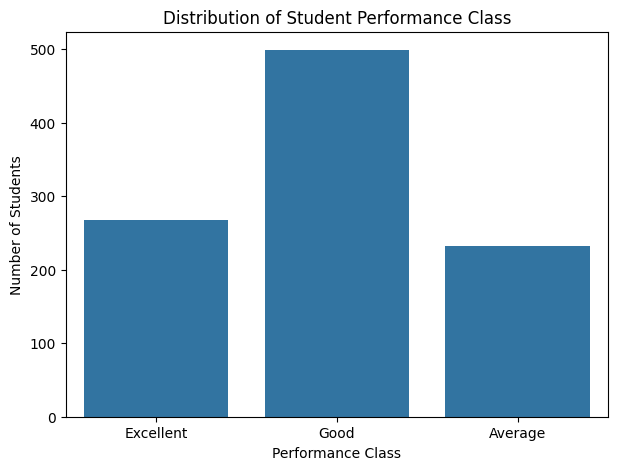

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Final_Result_Class")
plt.title("Distribution of Student Performance Class")
plt.xlabel("Performance Class")
plt.ylabel("Number of Students")
plt.show()

# **ACADEMIC FACTORS VS PERFORMANCE**
# PREVIOUS GPA

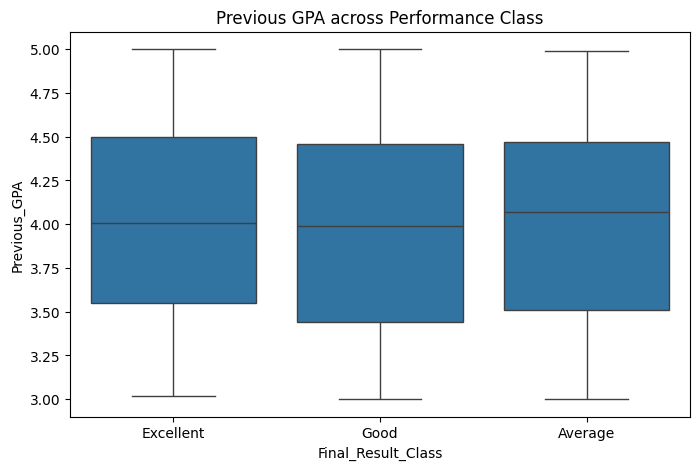

In [16]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Final_Result_Class", y="Previous_GPA")
plt.title("Previous GPA across Performance Class")

plt.show()

# SSC RESULT

<function matplotlib.pyplot.show(close=None, block=None)>

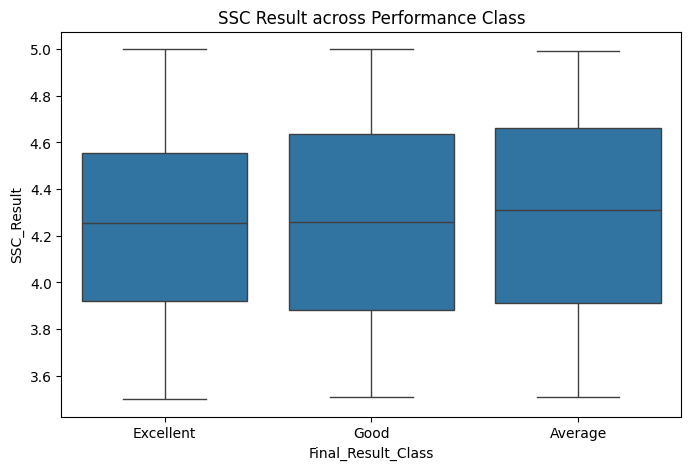

In [17]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x="Final_Result_Class",
    y="SSC_Result",
    data=df
)
plt.title("SSC Result across Performance Class")
plt.show


# **BEHAVIOURAL FACTORS**

# STUDY HOURS

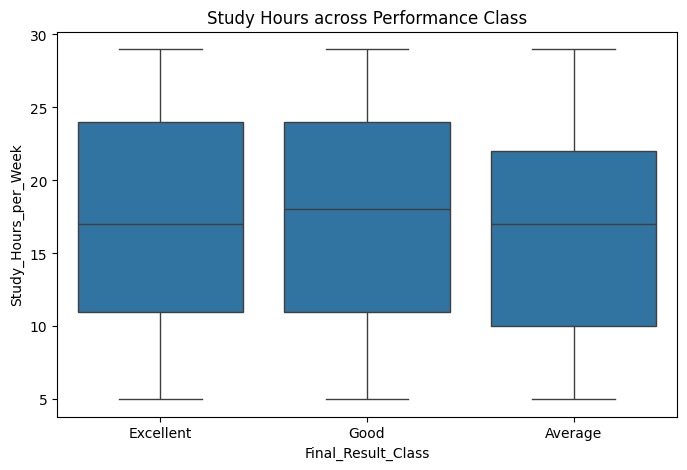

In [19]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Final_Result_Class", y="Study_Hours_per_Week")
plt.title("Study Hours across Performance Class")
plt.show()

# ATTENDANCE

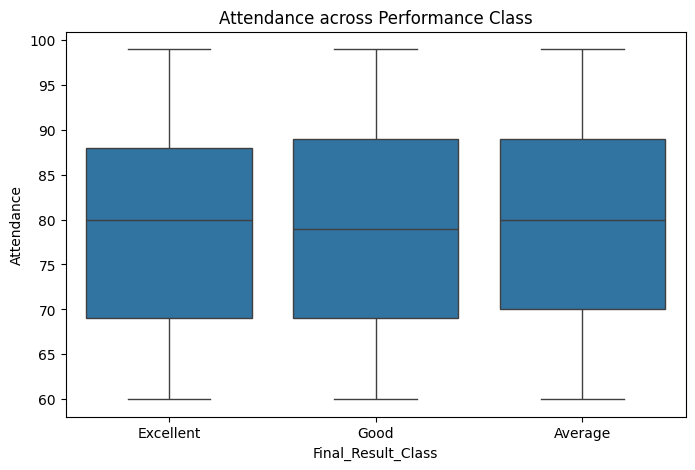

In [20]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Final_Result_Class", y="Attendance")
plt.title("Attendance across Performance Class")
plt.show()

# **Correlation Analysis**

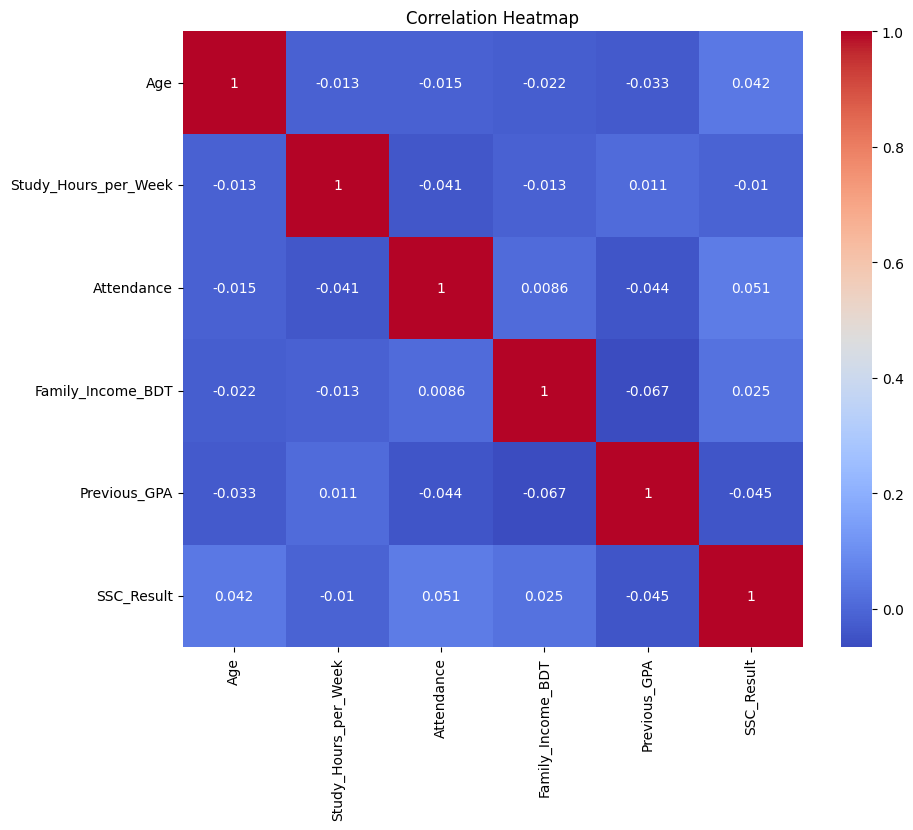

In [21]:
numeric_df=df.select_dtypes(include=["int64","float64"])
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# **MODEL BUILDING**

Machine Learning Classification models were developed to classify students into different academic performance categories.

# FEATURE AND TARGET SEPARATION

The dataset was separated into input features (X) and the target variable (y). Final_Result_Class was used as the target variable,while the remaining student characteristics were used as predictive features.

In [22]:
x=df.drop("Final_Result_Class", axis=1)
y=df["Final_Result_Class"]


In [26]:
x.head()

,Gender,Age,District,School_Type,Study_Hours_per_Week,Attendance,Parent_Education,Family_Income_BDT,Internet_Access,Private_Tuition,Previous_GPA,SSC_Result
0,1,16,6,0,11,70,0,49169,1,1,4.83,4.22
1,0,17,5,0,7,76,2,57947,0,0,4.96,4.09
2,1,15,0,0,27,63,1,57224,1,1,4.32,4.86
3,1,15,4,0,18,84,2,55865,0,0,4.63,3.54
4,1,15,4,1,28,89,1,35553,0,1,4.50,4.65


In [28]:
y[:5]

array([1, 1, 1, 2, 2])

In [29]:
y_encoder.classes_

array(['Average', 'Excellent', 'Good'], dtype=object)

# ENCODING CATEGORIAL VARIABLES

Categorial variables were converted into numerical values using label encoding. This transformation was necessary because ML algorithms require numerical inputs.

In [23]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for column in x.select_dtypes(include=["object"]).columns:
  x[column]=le.fit_transform(x[column])

In [24]:
y_encoder=LabelEncoder()
y=y_encoder.fit_transform(y)

# **TRAIN-TEST SPLIT**

The dataset was divided into training and testing sets to evaluate how well the model performs on unseen data. A stratified split was used to maintain the same proportion of performance categories in both datasets.

In [25]:
from sklearn.model_selection import train_test_split
x_train,x_test, y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [30]:
x_train.shape

(800, 12)

In [31]:
x_test.shape

(200, 12)

In [32]:
y_train.shape

(800,)

In [33]:
y_test.shape

(200,)

In [34]:
import numpy as np
np.unique(y_train,return_counts=True)

(array([0, 1, 2]), array([186, 215, 399]))

In [35]:
np.unique(y_test,return_counts=True)

(array([0, 1, 2]), array([ 47,  53, 100]))

# **LOGISTIC REGRESSION:BASELINE**

Logistic Regression was selected as the baseline classification model because it is simple, interpretable, and suitable for multiclass classification. It provides a benchmark against which more complex machine learning models can be compared.

In [36]:
from sklearn.linear_model import LogisticRegression
log_model=LogisticRegression(max_iter=1000)
log_model.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [37]:
log_predictions=log_model.predict(x_test)

In [38]:
log_predictions[:10]

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

# MODEL EVALUATION



In [39]:
from sklearn.metrics import (
accuracy_score,
precision_score,
recall_score,
f1_score,
classification_report,
confusion_matrix
)

accuracy = accuracy_score(y_test, log_predictions)
precision = precision_score(y_test, log_predictions, average="weighted")
recall = recall_score(y_test, log_predictions, average="weighted")
f1 = f1_score(y_test, log_predictions, average="weighted")

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.505
Precision: 0.38502525252525255
Recall: 0.505
F1 Score: 0.34520683343502134


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [40]:
print(classification_report(y_test,log_predictions))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        47
           1       0.50      0.02      0.04        53
           2       0.51      1.00      0.67       100

    accuracy                           0.51       200
   macro avg       0.34      0.34      0.24       200
weighted avg       0.39      0.51      0.35       200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


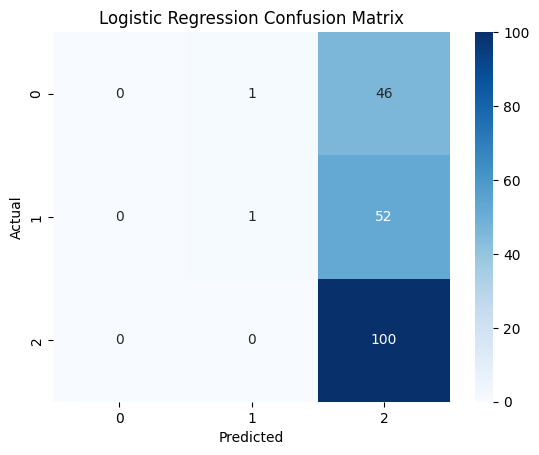

In [41]:
cm = confusion_matrix(y_test, log_predictions)

sns.heatmap(
cm,
annot=True,
fmt="d",
cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# **LOGISTIC REGRESSION BASELINE RESULTS**

The Logistic Regression baseline achieved an accuracy of 50.5%, with a weighted precision of 38.5%, weighted recall of 50.5%, and weighted F1-score of 34.5%.

These results indicate that the baseline model has limited ability to distinguish between the three student performance categories. The relatively low precision and F1-score suggest that the model makes a considerable number of incorrect classifications. Therefore, a more flexible machine learning algorithm will be explored to determine whether predictive performance can be improved.

# **RANDOM FOREST CLASSIFIER**

In [55]:
from sklearn.ensemble import RandomForestClassifier
rf_model=RandomForestClassifier(n_estimators=200,random_state=42)
rf_model.fit(x_train,y_train)
rf_predictions=rf_model.predict(x_test)

In [56]:
rf_accuracy = accuracy_score(y_test, rf_predictions)
rf_precision = precision_score(
y_test,
rf_predictions,
average="weighted"
)
rf_recall = recall_score(
y_test,
rf_predictions,
average="weighted"
)
rf_f1 = f1_score(
y_test,
rf_predictions,
average="weighted"
)

print("Accuracy:", rf_accuracy)
print("Precision:", rf_precision)
print("Recall:", rf_recall)
print("F1 Score:", rf_f1)

Accuracy: 0.505
Precision: 0.4846300211416491
Recall: 0.505
F1 Score: 0.4174096559378468


In [57]:
print(classification_report(y_test, rf_predictions))

              precision    recall  f1-score   support

           0       0.50      0.06      0.11        47
           1       0.41      0.17      0.24        53
           2       0.52      0.89      0.65       100

    accuracy                           0.51       200
   macro avg       0.48      0.37      0.34       200
weighted avg       0.48      0.51      0.42       200



# **RANDOM FOREST PERFORMANCE **

The Random Forest Classifier achieved an accuracy of 50.5%, weighted precision of 48.5%, weighted recall of 50.5%, and weighted F1-score of 41.7%.

Compared with the Logistic Regression baseline, Random Forest maintained the same accuracy and recall but improved weighted precision from 38.5% to 48.5% and weighted F1-score from 34.5% to 41.7%. This indicates an improvement in the quality and balance of predictions, although the overall predictive performance remains moderate.

Further model improvement through feature engineering and hyperparameter tuning will therefore be considered.

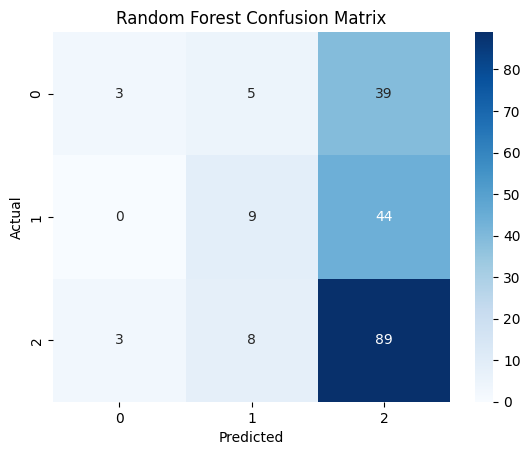

In [58]:
cm_rf=confusion_matrix(y_test,rf_predictions)
sns.heatmap(
cm_rf,
annot=True,
fmt="d",
cmap="Blues"
)
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# **HYPERPARAMETRE TUNING ON RANDOM FOREST**

In [59]:
from sklearn.model_selection import RandomizedSearchCV
param_grid = {
'n_estimators': [100, 200, 300,500],
'max_depth': [None, 5,10,15,20],
'min_samples_split': [2, 5, 10],
'min_samples_leaf': [1, 2, 4],
'max_features': ['sqrt', 'log2',None]
}
rf_tuning=RandomizedSearchCV(
RandomForestClassifier(random_state=42, class_weight='balanced'),
param_distributions=param_grid,
n_iter=20,
cv=5,
scoring="f1_weighted",
random_state=42,
n_jobs=-1
)
rf_tuning.fit(x_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=RandomForestClassifier(class_weight='balanced',
                                                    random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'max_depth': [None, 5, 10, 15, 20],
                                        'max_features': ['sqrt', 'log2', None],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 500]},
                   random_state=42, scoring='f1_weighted')

In [60]:
print("Best Parameters:")
print(rf_tuning.best_params_)

print("\nBest cross-validation F1 score:")
print(rf_tuning.best_score_)



Best Parameters:
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 20}

Best cross-validation F1 score:
0.3692869527778143


In [61]:
tuned_rf_predictions=rf_tuning.predict(x_test)


In [62]:
tuned_accuracy = accuracy_score(y_test, tuned_rf_predictions)
tuned_precision = precision_score(
y_test,
tuned_rf_predictions,
average="weighted"
)
tuned_recall = recall_score(
y_test,
tuned_rf_predictions,
average="weighted"
)
tuned_f1 = f1_score(
y_test,
tuned_rf_predictions,
average="weighted"
)

print("Accuracy:", tuned_accuracy)
print("Precision:", tuned_precision)
print("Recall:", tuned_recall)
print("F1 Score:", tuned_f1)

Accuracy: 0.505
Precision: 0.4526748084291188
Recall: 0.505
F1 Score: 0.41000667308429206


In [52]:
print(classification_report(y_test, tuned_rf_predictions))

              precision    recall  f1-score   support

           0       0.25      0.06      0.10        47
           1       0.33      0.15      0.21        53
           2       0.52      0.86      0.65       100

    accuracy                           0.48       200
   macro avg       0.37      0.36      0.32       200
weighted avg       0.41      0.48      0.40       200



In [63]:
!pip install xgboost -q

In [65]:
from xgboost import XGBClassifier
xgb_model=XGBClassifier(
    random_state=42,
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss'
)
xgb_model.fit(x_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None, num_class=3, ...)

In [66]:
xgb_predictions=xgb_model.predict(x_test)

In [67]:
xgb_accuracy = accuracy_score(y_test, xgb_predictions)
xgb_precision = precision_score(
y_test,
xgb_predictions,
average="weighted"
)
xgb_recall = recall_score(
y_test,
xgb_predictions,
average="weighted"
)
xgb_f1 = f1_score(
y_test,
xgb_predictions,
average="weighted"
)

print("Accuracy:", xgb_accuracy)
print("Precision:", xgb_precision)
print("Recall:", xgb_recall)
print("F1 Score:", xgb_f1)

Accuracy: 0.475
Precision: 0.40178070175438596
Recall: 0.475
F1 Score: 0.41196120458686103


In [68]:
print(classification_report(y_test, xgb_predictions))

              precision    recall  f1-score   support

           0       0.20      0.06      0.10        47
           1       0.33      0.21      0.26        53
           2       0.53      0.81      0.64       100

    accuracy                           0.47       200
   macro avg       0.36      0.36      0.33       200
weighted avg       0.40      0.47      0.41       200



In [70]:
df.groupby("Final_Result_Class")[[
    "Previous_GPA",
    "SSC_Result",
    "Study_Hours_per_Week",
    "Attendance"
]].mean()

,Previous_GPA,SSC_Result,Study_Hours_per_Week,Attendance
Final_Result_Class,,,,
Average,4.021803,4.278283,16.450644,79.622318
Excellent,4.016679,4.253619,17.238806,79.365672
Good,3.970701,4.248717,17.332665,79.318637


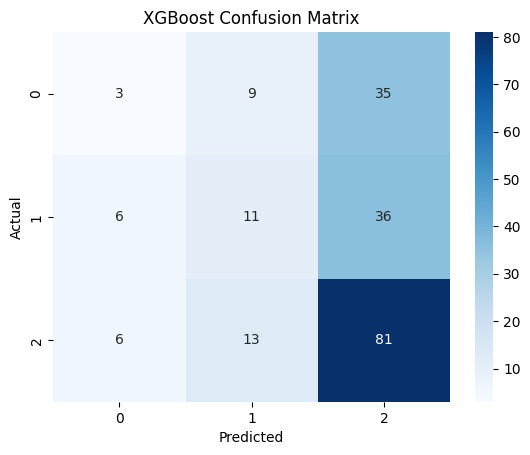

In [71]:
cm_xgb = confusion_matrix(y_test, xgb_predictions)
sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [73]:
from sklearn.ensemble import VotingClassifier
voting_classifier = VotingClassifier(
    estimators=[
        ('rf_model', rf_model),
        ('xgb_model', xgb_model)
    ],
    voting='soft'
)
voting_classifier.fit(x_train, y_train)
ensemble_predictions=voting_classifier.predict(x_test)

In [74]:
ensemble_accuracy = accuracy_score(y_test, ensemble_predictions)
ensemble_precision = precision_score(
    y_test,
    ensemble_predictions,
    average="weighted"
)
ensemble_recall = recall_score(
    y_test,
    ensemble_predictions,
    average="weighted"
)
ensemble_f1 = f1_score(
    y_test,
    ensemble_predictions,
    average="weighted"
)

print("Ensemble Accuracy:", ensemble_accuracy)
print("Ensemble Precision:", ensemble_precision)
print("Ensemble Recall:", ensemble_recall)
print("Ensemble F1 Score:", ensemble_f1)

Ensemble Accuracy: 0.485
Ensemble Precision: 0.40588434446716654
Ensemble Recall: 0.485
Ensemble F1 Score: 0.40593514441998535


In [75]:
print(classification_report(y_test, ensemble_predictions))

              precision    recall  f1-score   support

           0       0.20      0.04      0.07        47
           1       0.37      0.19      0.25        53
           2       0.52      0.85      0.65       100

    accuracy                           0.48       200
   macro avg       0.36      0.36      0.32       200
weighted avg       0.41      0.48      0.41       200



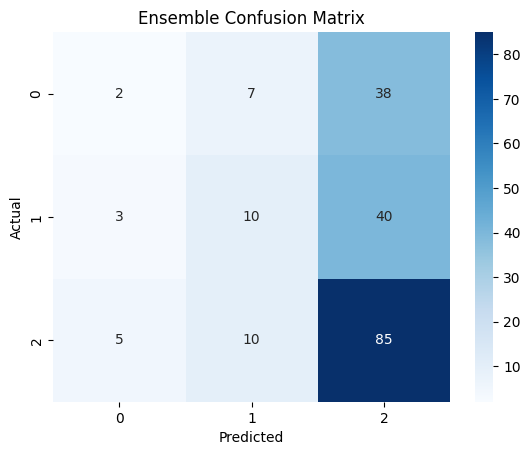

In [76]:
cm_ensemble = confusion_matrix(y_test, ensemble_predictions)
sns.heatmap(
    cm_ensemble,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title("Ensemble Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# **CONCLUSION**

After evaluating multiple classification models, Random Forest Classifier was selected as the final model. Although the accuracy remained similar to the Logistic Regression baseline, Random Forest achieved improved precision and F1-score, indicating better overall classification performance.

The model was selected because it is capable of capturing nonlinear relationships between student characteristics and academic performance, while also providing feature importance measures that improve model interpretability.

The results also suggest that the available features may have limited predictive power for distinguishing between student performance categories.

# **DEPLYMENT**

In [78]:
import joblib
joblib.dump(rf_model,"student_performance_model.pkl")

['student_performance_model.pkl']

In [80]:
joblib.dump(le,"feature_encoder.pkl")
joblib.dump(y_encoder,"target_encoder.pkl")

['target_encoder.pkl']

In [81]:
joblib.dump(le,"feature_encoder.pkl")


['feature_encoder.pkl']